In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Libraries needed

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from huggingface_hub import create_repo, upload_folder

Path to dataset and Meta data

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

# Metadata CSV created from your local preparation script
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

# Output folder for this model
OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_2_efficientnetv2b0_rgb_pretrained")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


Loading dataset

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64


In [ ]:
df["image_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "rgb.png")
)

df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists())

print("Missing images:", (~df["image_exists"]).sum())

df = df[df["image_exists"]].copy()

print(df["split"].value_counts())
print(df.head())


Missing images: 0
split
train    2421
test      507
val       334
Name: count, dtype: int64
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                          image_path  image_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
1  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
2  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
3  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
4  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  


Creating Training / Validation and testing split

In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))


Train: 2421
Val:   334
Test:  507


Parameters

In [ ]:
IMG_HEIGHT = 640
IMG_WIDTH  = 480
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE
EPOCHS     = 300

Data loading

In [ ]:
def load_image_and_label(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)   # keep in [0,255]
    label = tf.cast(label, tf.float32)
    return image, label


def make_dataset(dataframe, batch_size=8, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_image_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

Model architecture

In [ ]:
from tensorflow.keras.applications import EfficientNetV2B0

base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# First stage: freeze pretrained backbone
base_model.trainable = False

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

# Forward pass through pretrained backbone
x = base_model(inputs, training=False)

# Head for regression
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.3, name="dropout")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
x = layers.Dropout(0.2, name="dropout_2")(x)
outputs = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(inputs, outputs, name="efficientnetv2b0_rgb_pretrained_carb_regression")
model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetv2b0_rgb_pretrained_carb_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 640, 480, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 20, 15, 1280)   │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,083,409 (23.21 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

The model will be based on the EfficientNetV2B0 as the pretrained model due to that model being proven to perform the best on this dataset. There is a regression head trained on top of this model which will be based on the training data here.

Compile

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

Callbacks

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=150,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=125,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

Train

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/300
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - loss: 424.8573 - mae: 12.6603 - mse: 424.8573
Epoch 1: val_loss improved from None to 144.66165, saving model to /content/drive/MyDrive/Speciale/Models/efficientnetv2b0_rgb_pretrained/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/efficientnetv2b0_rgb_pretrained/best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 609s 4s/step - loss: 488.3886 - mae: 11.3691 - mse: 488.3886 - val_loss: 144.6617 - val_mae: 8.7171 - val_mse: 144.6617 - learning_rate: 0.0010
Epoch 2/300
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: 401.3943 - mae: 9.4779 - mse: 401.3943
Epoch 2: val_loss improved from 144.66165 to 132.21892, saving model to /content/drive/MyDrive/Speciale/Models/efficientnetv2b0_rgb_pretrained/best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/efficientnetv2b0_rgb_pretrained/best_model.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 40s 264ms/step - loss: 431.5184 - m

Plotting

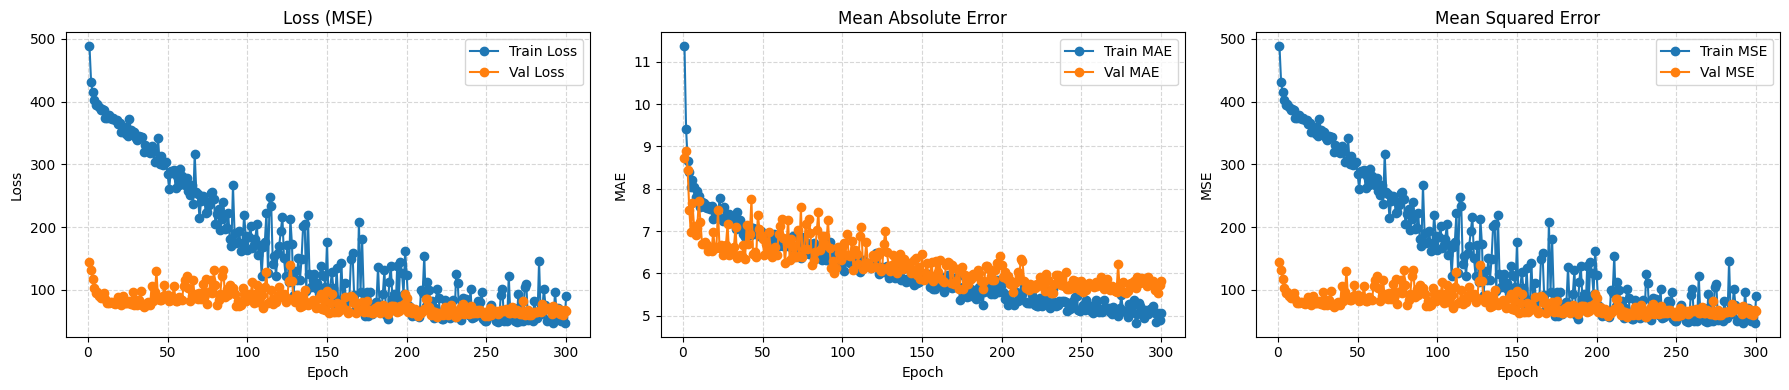

Best val_loss: 57.3749 at epoch 231
Val MAE at best epoch: 5.5472
Val MSE at best epoch: 57.3749


In [ ]:
def plot_metrics(history):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title("Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)

    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title("Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")

    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")


plot_metrics(history)


Evaluation on test set

In [ ]:
loaded_model = tf.keras.models.load_model(str(OUTPUT_DIR / "best_model.keras"))

In [ ]:
loaded_model_test_results = loaded_model.evaluate(test_dataset, return_dict=True)
print(loaded_model_test_results)

32/32 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - loss: 86.5800 - mae: 6.4522 - mse: 86.5800
{'loss': 86.58003234863281, 'mae': 6.4522385597229, 'mse': 86.58003234863281}


In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)